In [661]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [ ]:
# path = r'd:\Projects\Tr_lights\data\20250512_131114_ann\20250512_131114_c0\9194.296.jpg'
path = r'./image.jpg'
img = Image.open(path)
img = np.array(img, dtype=np.uint8)
img.shape

In [ ]:
#  центр колеи
plt.figure(figsize=(15, 10))
plt.imshow(img)
x_c = 722
plt.plot([x_c], [715], marker='+', color='red', linewidth=0)
plt.plot([x_c, x_c], [0, 710])


In [ ]:
# # первый вариант

# img = Image.open(r'./image.jpg')
# img = np.array(img)[320:,400:1000,:]
# w, h = img.shape[1], img.shape[0]
# # Координаты углов трапеции по картинке (тут получены вручную)
# top_left = [230, 158]
# top_right = [470, 158]
# bottom_left = [155, 260]
# bottom_right = [558, 260]

# img_points = np.float32([top_left, top_right, bottom_left, bottom_right])
# wmm = 200
# hmm = 250
# real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# # Вычисление матрицы коррекции перспективы
# pmatrix = cv2.getPerspectiveTransform(img_points, real_pointst)

# # выпрямленная картинка в пределах угла трапеции
# cropped = cv2.warpPerspective(img, pmatrix, (wmm, hmm))
# # Пересчет всей картинки (не только в пределах координат трапеции)

# # Углы исходной каринки
# corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# # Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
# t_corners = cv2.perspectiveTransform(corners, pmatrix)
# # Границы изображения в реальном пространстве
# x_min, y_min = t_corners.min(axis=0).ravel()
# x_max, y_max = t_corners.max(axis=0).ravel()
# print('x_min, x_max, y_min, y_max', x_min, x_max, y_min, y_max)
# # Размеры области
# new_w = int(np.ceil(x_max - x_min))
# new_h = int(np.ceil(y_max - y_min))

# # Матрица переноса (сдвиг картинки в положительную область
# pmatrix_shift = np.array([[3, 0, 1300],
#                           [0, 2.5, 1600],
#                           [0, 0, 1]])
# # Произведение матрицы переноса и матрицы перспективы
# pmatrix_new = pmatrix_shift @ pmatrix

# # полная картинка
# corr = cv2.warpPerspective(np.array(img), pmatrix_new, (2600, 2500))

# plt.imshow(corr)
# x = corr.shape[1] // 2
# plt.plot([x, x], [0, corr.shape[0]-1])

In [ ]:
img = Image.open(r'./image.jpg')
img = np.array(img)
img = img[320:, x_c-300:x_c+300,:]
w, h = img.shape[1], img.shape[0]

fig, (asrc) = plt.subplots(1, 1, figsize=(10, 8))

# Координаты углов трапеции по картинке (тут получены вручную)
top_left = [260, 165]
top_right = [452, 165]
bottom_left = [223, 290]
bottom_right = [558, 290]

img_points = np.float32([top_left, top_right, bottom_left, bottom_right])

# Показать кординаты углов на картинке
asrc.imshow(img)
asrc.plot(*img_points.T, marker='+', color='red', linewidth=0)
print(img.shape)

In [ ]:
# wmm = 150
# hmm = 222
wmm = 200
hmm = int(wmm * 2.055)
print(wmm, hmm)
real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# Вычисление матрицы коррекции перспективы
pmatrix = cv2.getPerspectiveTransform(img_points, real_pointst)

# выпрямленная картинка в пределах угла трапеции
cropped = cv2.warpPerspective(img, pmatrix, (wmm, hmm))

# Показать выпрямленную картинку
# plt.axis('equal')
plt.imshow(cropped)
print(cropped.shape)

In [ ]:
# Пересчет всей картинки (не только в пределах координат трапеции)

# Углы исходной каринки
corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
t_corners = cv2.perspectiveTransform(corners, pmatrix)
# Границы изображения в реальном пространстве
x_min, y_min = t_corners.min(axis=0).ravel()
x_max, y_max = t_corners.max(axis=0).ravel()
print('x_min, x_max, y_min, y_max', x_min, x_max, y_min, y_max)
# Размеры области
new_w = int(np.ceil(x_max - x_min))
new_h = int(np.ceil(y_max - y_min))

# Матрица переноса (сдвиг картинки в положительную область
# pmatrix_shift = np.array([[1, 0, -x_min],
#                           [0, 1, -y_min],
#                           [0, 0, 1]])
# pmatrix_new = pmatrix @ pmatrix_shift
# corr = cv.warpPerspective(np.array(img), pmatrix_new, (new_w, new_h))

pmatrix_shift = np.array([[3, 0, 1150],
                          [0, 2.5, 1000],
                          [0, 0, 1]])

# # Матрица переноса (сдвиг картинки в положительную область
pmatrix_new = pmatrix_shift @ pmatrix

# # полная картинка
corr = cv2.warpPerspective(np.array(img), pmatrix_new, (2600, 2400))

plt.imshow(corr)
x = corr.shape[1] // 2
plt.plot([x, x], [0, corr.shape[0]-1])

print(corr.shape)


In [662]:
src = r'./data/2'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

for f in msk_fs:
    match = re.search(r'(\d+\.\d)', f)
    if match:
        result = match.group(1)
        coord.append(float(result))


In [ ]:
np.save('pmatrix_new.npy', pmatrix_new)

In [663]:
np.load('pmatrix_new.npy')

array([[ 1.85185185e+02,  4.60864198e+02, -5.60425926e+04],
       [ 6.54717325e-14,  1.20299383e+03, -1.39234722e+05],
       [ 6.54717325e-17,  3.53086420e-01,  1.00000000e+00]])

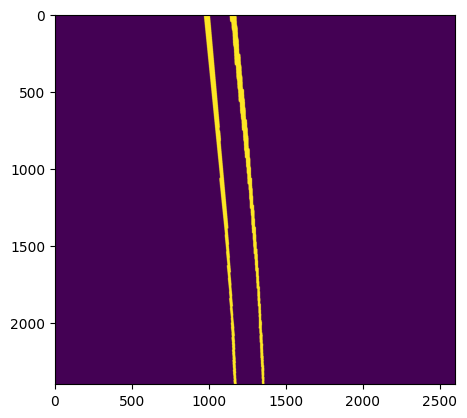

In [666]:
def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = mask[320:, x_c-300:x_c+300] # так обрезалось при расчете трапеции
    res = cv2.warpPerspective(np.array(mask), pmatrix_new, (2600, 2400))
    return res

fig, ax = plt.subplots()

mask_pr = load_warp(msk_fs[25])

ax.imshow(mask_pr)

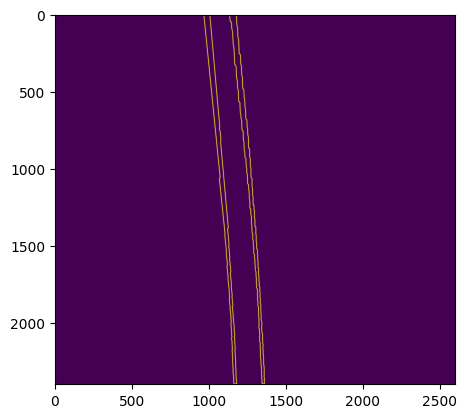

In [667]:
mask_cont = np.zeros_like(mask_pr)
contours, _ = cv2.findContours(mask_pr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(mask_cont, contours, -1, 1, 3)

plt.imshow(mask_cont)

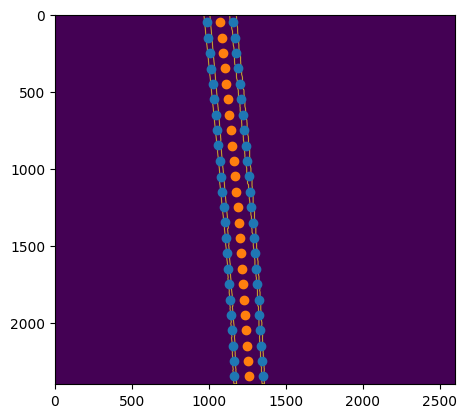

In [668]:
# картинку брал по частям гориз срезами, считал  центр масс контуров

centroids = []
st = 0
step = 100
for en in range(step, mask_cont.shape[1], step):

    contours, _ = cv2.findContours(mask_pr[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    for contour in contours:
        M = cv2.moments(contour)
        if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            centroids.append((cx, cy+st))

    st += step

X = np.array(centroids)[:, 0]
Y = np.array(centroids)[:, 1]

diff = np.diff(Y)

# средние точки между центрами масс кусков контуров
mid_p = []
for i, v in enumerate(diff):
    if v < 3:
        mid_p.append([X[i] - int((X[i] - X[i+1]) / 2), Y[i]])
mid_p = np.array(mid_p)

plt.imshow(mask_cont)
plt.scatter(X, Y)
plt.scatter(mid_p[:, 0], mid_p[:, 1]);


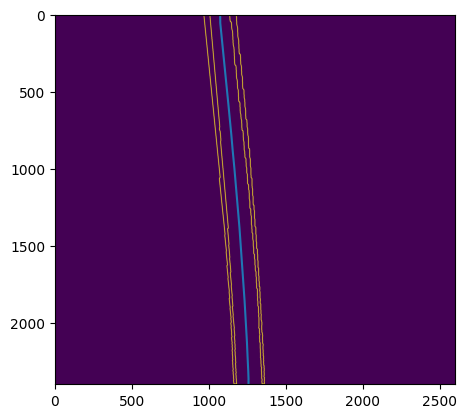

In [669]:
# Интеролировать серединки

y_centr = np.arange(mask_cont.shape[0])
x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])
plt.imshow(mask_cont)
plt.plot(x_centr, y_centr);

# сделать функцию по такому типу, но обратную,
# когда на вход смещенный у, на выходе х

In [ ]:
# mask_cont = Image.fromarray(mask_cont)
# mask_cont.save('mask_cont.jpg')

In [670]:
# открывается следующая картинка, выравнивается, вырезается ее часть до след координаты
# и вставляется в основное, совмещая центры
# взять нижнюю точку между рельсами на след картинке и учитывая координаты (у) поставить ее на центральной линии.

mask_nxt = load_warp(msk_fs[24])
mask_nxt_p = mask_nxt[-181:, :]
print(mask_nxt_p.shape)

# простой вариант на попробовать
# находит центр между рельсами
x_min = np.where(mask_nxt[-2, :] == 1)[0][0]
x_max = np.where(mask_nxt[-2, :] == 1)[0][-1]
m_p = x_min + ((x_max - x_min) // 2)

plt.imshow(mask_nxt_p)
plt.scatter(m_p, mask_nxt_p.shape[0]-1)
print(m_p)

# тест сопоставления
mask_test = np.zeros_like(mask_nxt_p)
t_p = 500
bord = 200

mask_test[:, t_p:t_p+bord] = mask_nxt_p[:, m_p:m_p+bord]  # справа от точки
mask_test[:, t_p-bord:t_p] = mask_nxt_p[:, m_p-bord:m_p]  # справа от точки

plt.imshow(mask_test)

(181, 2600)

### проба в цикл

In [786]:
# 25 # 16054.942 основ
# 24 # 16053.3 след
# ...

# 8.8мм в однм пикселе

# если идти вперед, отступ в пикселях на центр-ой линии
def coord2pix(c1, c2):
    return abs(int(((c1 - c2) * 1000) / 8.8))


# координаты в target points на изобр

st_p = coord[25]  # стартовая картинка/коорд
t_ps = []
t_v = 0           # temp val
for c in coord[24:12:-1]:
    print(c)
    res = coord2pix(st_p, c)
    res += t_v
    t_v = res
    t_ps.append(res)
    st_p = c

t_ps
# [181, 362, 532, 713, 883, 1053, 1223, 1393, 1608]


16053.3
16051.7
16050.1
16048.4
16046.8
16045.2
16043.6
16042.0
16040.3
16038.7
16037.1
16035.5


[181, 362, 543, 736, 917, 1098, 1279, 1460, 1653, 1834, 2015, 2196]

181 181 ./data/2\16053.330.npy
181 362 ./data/2\16051.717.npy
181 543 ./data/2\16050.105.npy
193 736 ./data/2\16048.492.npy
181 917 ./data/2\16046.874.npy
181 1098 ./data/2\16045.259.npy
181 1279 ./data/2\16043.640.npy
181 1460 ./data/2\16042.020.npy
193 1653 ./data/2\16040.397.npy
181 1834 ./data/2\16038.768.npy
181 2015 ./data/2\16037.149.npy
181 2196 ./data/2\16035.515.npy


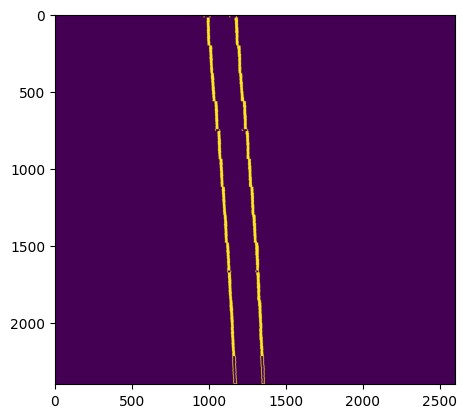

In [787]:
# проба в цикл

# для высот картинок

diff = np.diff(t_ps, prepend=0)

mask_res = mask_cont.copy()
bord = 200  # область захвата

fig, ax = plt.subplots()

for h, p, name in zip(diff, t_ps, msk_fs[24:12:-1]):  # порядок другой - коор идут вверх, а поезд едет в обратном напр
    print(h, p, name)
    mask_nxt = load_warp(name)
    mask_nxt_p = mask_nxt[-h:, :]
    # точка между рельсами, по ней будет срез
    x_min = np.where(mask_nxt[-4, :] == 1)[0][0]
    x_max = np.where(mask_nxt[-4, :] == 1)[0][-1]
    m_p = x_min + ((x_max - x_min) // 2)

    t_p = round(x_centr[-p])

    mask_res[-p-h:-p, t_p:t_p+bord] = mask_nxt_p[:, m_p:m_p+bord]
    mask_res[-p-h:-p, t_p-bord:t_p] = mask_nxt_p[:, m_p-bord:m_p]

    # plt.axhline(round(y_centr[-p]))
    # plt.imshow(mask_nxt_p)
    # plt.show()

plt.imshow(mask_res)

# TODO на стыках встречаются пробелы, хотя на исходниках всё норм. косяк.jpg


In [905]:
mask_res.shape[1]-p

2419

181 181 ./data/2\16053.330.npy
181 362 ./data/2\16051.717.npy
181 543 ./data/2\16050.105.npy
193 736 ./data/2\16048.492.npy
181 917 ./data/2\16046.874.npy
181 1098 ./data/2\16045.259.npy
181 1279 ./data/2\16043.640.npy
181 1460 ./data/2\16042.020.npy
193 1653 ./data/2\16040.397.npy
181 1834 ./data/2\16038.768.npy
181 2015 ./data/2\16037.149.npy
181 2196 ./data/2\16035.515.npy


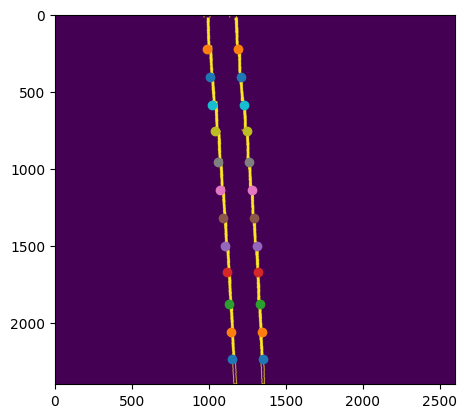

In [ ]:
# ТЕСТОВЫЦ ВАРИАНТ
# пока куски по точкам
# для высот картинок

diff = np.diff(t_ps, prepend=0)

mask_res = mask_cont.copy()
bord = 200  # область захвата

fig, ax = plt.subplots()

for h, p, name in zip(diff, t_ps, msk_fs[24:12:-1]):  # порядок другой - коор идут вверх, а поезд едет в обратном напр
    print(h, p, name)
    mask_nxt = load_warp(name)
    mask_nxt_p = mask_nxt[-h:, :]
    # точка между рельсами, по ней будет срез
    y = -4

    x_min = np.where(mask_nxt[y, :] == 1)[0][0]
    x_max = np.where(mask_nxt[y, :] == 1)[0][-1]
    m_p = x_min + ((x_max - x_min) // 2)

    t_p = round(x_centr[-p])

    # точки входа рельсов на осн изобр
    # _l = m_p - x_min
    # _r = x_max - m_p
    # plt.scatter([t_p - _l, t_p + _r], [mask_res.shape[1]-p-h, mask_res.shape[1]-p-h])

    # перенос срезов на осн изобр
    mask_res[-p-h:-p, t_p:t_p+bord] = mask_nxt_p[:, m_p:m_p+bord]
    mask_res[-p-h:-p, t_p-bord:t_p] = mask_nxt_p[:, m_p-bord:m_p]



    # plt.axhline(round(y_centr[-p]))
    # plt.imshow(mask_nxt_p)
    # plt.show()

plt.imshow(mask_res)

# TODO на стыках встречаются пробелы, хотя на исходниках всё норм. косяк.jpg


(4, 2)

array([1000, 1000,  181,  181])

(np.float64(97.49999999999999),
 np.float64(152.5),
 np.float64(-9.0),
 np.float64(189.0))

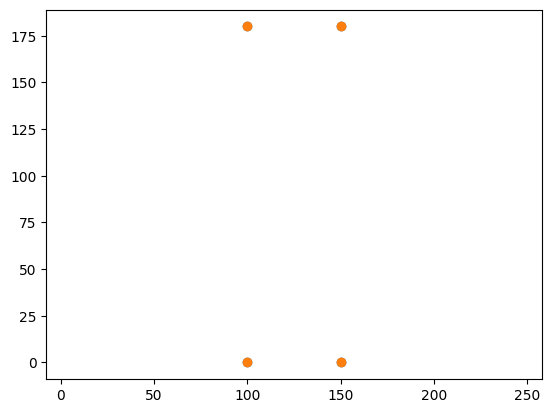

In [ ]:
# x, y  bl br tr tl

# rect = np.array([[100, 0], [150, 0], [150, mask_nxt_p.shape[0]], [100, mask_nxt_p.shape[0]]])
rect = np.array([[100, 0],
                 [150, 0],
                 [150, 180],
                 [100, 180]])
# Точка, вокруг которой повернуть
pivot_point = np.array([125, 90])

# Угол поворота
theta = np.radians(180)
c, s = np.cos(theta), np.sin(theta)
rotation_matrix = np.array([
    [c, -s],
    [s,  c]
])

shifted_rect = rect - pivot_point


rotated_shit_rectangle = (rotation_matrix @ shifted_rect.T).T

rotated_rectangle = rotated_shit_rectangle + pivot_point


plt.scatter(rect[:, 0], rect[:, 1])
plt.scatter(rotated_rectangle[:, 0], rotated_rectangle[:, 1])
plt.axis('equal')


In [ ]:
rotated_rectangle

array([[101.50768448,  -8.55050358],
       [148.49231552,   8.55050358],
       [ 86.92868972, 177.69517532],
       [ 39.94405868, 160.59416816]])

In [952]:
rotated_rectangle[:, 0]

array([101.50768448, 148.49231552,  86.92868972,  39.94405868])

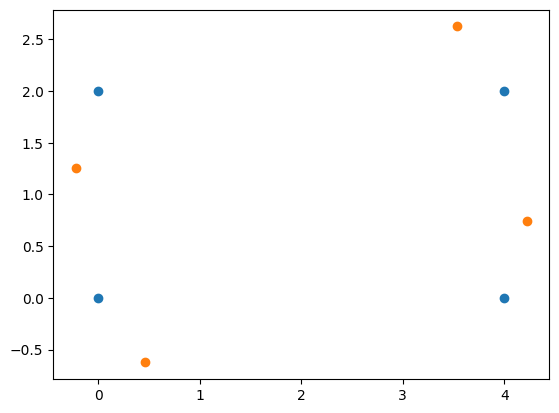

In [944]:
# Координаты прямоугольника
rectangle = np.array([
    [0, 0],
    [4, 0],
    [4, 2],
    [0, 2]
])

# Точка, вокруг которой хотим повернуть (например, центр прямоугольника)
pivot_point = np.array([2, 1])

# Угол поворота
theta = np.radians(20)
c, s = np.cos(theta), np.sin(theta)
rotation_matrix = np.array([
    [c, -s],
    [s,  c]
])

# 1. Переносим прямоугольник так, чтобы точка pivot оказалась в (0, 0)
shifted_rect = rectangle - pivot_point

# 2. Поворачиваем сдвинутые точки
rotated_shifted_rect = (rotation_matrix @ shifted_rect.T).T

# 3. Возвращаем прямоугольник обратно на исходное место
rotated_rectangle = rotated_shifted_rect + pivot_point

plt.scatter(rectangle[:, 0], rectangle[:, 1])
plt.scatter(rotated_rectangle[:, 0], rotated_rectangle[:, 1])

In [916]:
rotated_rectangle

array([[ 939.69262079,  939.69262079, -342.94585063, -171.93577896],
       [ 342.02014333,  342.02014333, 1471.44457712, 1001.59826673]])

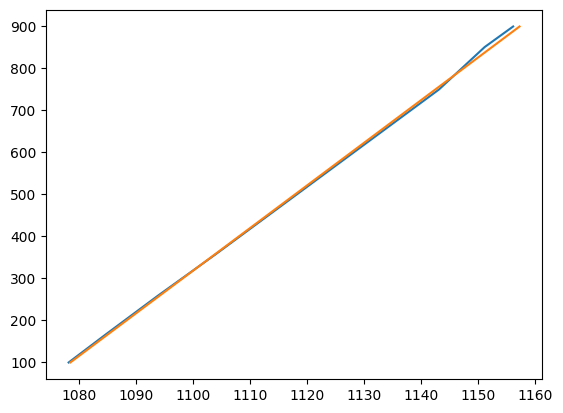

In [ ]:


x = x_centr[100:900]
y = y_centr[100:900]

coef = np.polyfit(y, x, 1)
f = np.poly1d(coef)
x_lin = f(y)

plt.plot(x_centr[100:900], y_centr[100:900])
plt.plot(x_lin, y)


In [ ]:
def get_perp(x_arr, y_arr):
    coef = np.polyfit(y_arr, x_arr, 1)
    f = np.poly1d(coef)
    x_lin = f(y_arr)


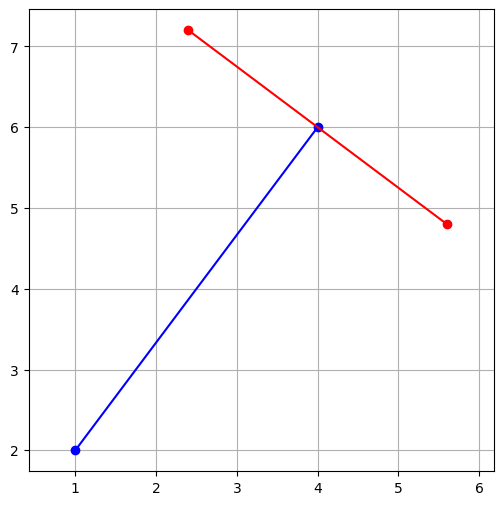

In [848]:
# 1. Исходная наклонная линия (отрезки x и y)
p1 = np.array([1.0, 2.0])  # Начало
p2 = np.array([4.0, 6.0])  # Конец (точка пересечения)

# 2. Расчет направляющего вектора линии
v = p2 - p1

# 3. Нахождение перпендикулярного вектора (поворот на 90 градусов)
# Для вектора (x, y) перпендикуляр равен (-y, x)
v_perp = np.array([-v[1], v[0]])

# 4. Нормирование перпендикуляра (задаем нужную длину, например, 2 единицы)
length = 2.0  # будет равно bord
v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length

# 5. Вычисление конечной точки перпендикуляра
p3 = p2 + v_perp_normalized
p4 = p2 - v_perp_normalized


plt.figure(figsize=(6, 6))
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "b-o")
plt.plot([p3[0], p4[0]], [p3[1], p4[1]], "r-o")

plt.grid(True)
plt.axis("equal")
plt.show()
